In [0]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Mini Capstone Project").getOrCreate()
with open('flights.csv', 'w') as f:    
    f.write('flight_id,airline,from_city,to_city,duration,status\n')
    f.write('F101,Indigo,Hyderabad,Delhi,140,On Time\n')
    f.write('F102,Air India,Mumbai,Chennai,120,Delayed\n')
    f.write('F103,Vistara,Bangalore,Hyderabad,90,On Time\n')
    f.write('F104,Indigo,Delhi,Mumbai,130,Cancelled\n')
    f.write('F105,Air India,Chennai,Bangalore,80,On Time\n')
    f.write('F106,Akasa,Pune,Delhi,150,Delayed\n')
    f.write('F107,Vistara,Hyderabad,Kolkata,160,On Time\n')
    f.write('F108,Indigo,Mumbai,Hyderabad,110,On Time\n')
    f.write('F109,Akasa,Delhi,Chennai,145,Delayed\n')
    f.write('F110,Air India,Bangalore,Mumbai,95,On Time\n')
    f.write('F111,Indigo,Hyderabad,Goa,75,On Time\n')
    f.write('F112,Vistara,Goa,Delhi,150,Cancelled\n')
    f.write('F113,Akasa,Chennai,Pune,100,On Time\n')
    f.write('F114,Air India,Kolkata,Bangalore,170,Delayed\n')
    f.write('F115,Indigo,Delhi,Hyderabad,135,On Time\n')

In [0]:
%%writefile bookings.csv
booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01
B1002,F101,Priya Reddy,Business,22000,2026-06-01
B1003,F102,Amit Kumar,Economy,9000,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02
B1005,F104,Farhan Ali,Economy,7500,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05
B1011,F110,David Thomas,Economy,8000,2026-06-06
B1012,F111,Ayesha Khan,Premium Economy,16000,2026-06-06
B1013,F112,Rohit Sharma,Economy,7000,2026-06-07
B1014,F113,Pooja Mehta,Business,24000,2026-06-07
B1015,F114,Sanjay Gupta,Economy,10500,2026-06-08
B1016,F115,Divya Iyer,Premium Economy,18000,2026-06-08
B1017,F101,Vikram Singh,Economy,8500,2026-06-09
B1018,F103,Anjali Rao,Business,23000,2026-06-09
B1019,F107,Faiz Ahmed,Economy,9500,2026-06-10
B1020,F110,Megha Kapoor,Premium Economy,15500,2026-06-10

Writing bookings.csv


### Part 1 : Data Ingestion


In [0]:
flights_df = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load("file:/Workspace/flights.csv")
flights_df.printSchema()

root
 |-- flight_id: string (nullable = true)
 |-- airline: string (nullable = true)
 |-- from_city: string (nullable = true)
 |-- to_city: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- status: string (nullable = true)



In [0]:
bookings_df = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load("file:/Workspace/bookings.csv")
display(bookings_df)

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01
B1002,F101,Priya Reddy,Business,22000,2026-06-01
B1003,F102,Amit Kumar,Economy,9000,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02
B1005,F104,Farhan Ali,Economy,7500,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05


In [0]:
from pyspark.sql.functions import *
import json

passenger_json = [
  {
    "passenger_name": "Rahul Sharma",
    "meal": "Veg",
    "seat": "Window",
    "extra_baggage": True
  },
  {
    "passenger_name": "Priya Reddy",
    "meal": "Non-Veg",
    "seat": "Aisle",
    "extra_baggage": False
  },
  {
    "passenger_name": "Amit Kumar",
    "meal": "Veg",
    "seat": "Middle",
    "extra_baggage": False
  },
  {
    "passenger_name": "Sneha Patel",
    "meal": "Jain",
    "seat": "Window",
    "extra_baggage": True
  },
  {
    "passenger_name": "Farhan Ali",
    "meal": "Non-Veg",
    "seat": "Aisle",
    "extra_baggage": False
  },
  {
    "passenger_name": "Neha Singh",
    "meal": "Veg",
    "seat": "Window",
    "extra_baggage": True
  },
  {
    "passenger_name": "Arjun Verma",
    "meal": "Veg",
    "seat": "Middle",
    "extra_baggage": False
  },
  {
    "passenger_name": "Meera Nair",
    "meal": "Jain",
    "seat": "Window",
    "extra_baggage": True
  },
  {
    "passenger_name": "Kiran Rao",
    "meal": "Veg",
    "seat": "Aisle",
    "extra_baggage": False
  },
  {
    "passenger_name": "Nisha Reddy",
    "meal": "Non-Veg",
    "seat": "Window",
    "extra_baggage": True
  },
  {
    "passenger_name": "David Thomas",
    "meal": "Veg",
    "seat": "Middle",
    "extra_baggage": False
  },
  {
    "passenger_name": "Ayesha Khan",
    "meal": "Jain",
    "seat": "Window",
    "extra_baggage": True
  },
  {
    "passenger_name": "Rohit Sharma",
    "meal": "Veg",
    "seat": "Aisle",
    "extra_baggage": False
  },
  {
    "passenger_name": "Pooja Mehta",
    "meal": "Non-Veg",
    "seat": "Window",
    "extra_baggage": True
  },
  {
    "passenger_name": "Sanjay Gupta",
    "meal": "Veg",
    "seat": "Middle",
    "extra_baggage": False
  },
  {
    "passenger_name": "Divya Iyer",
    "meal": "Jain",
    "seat": "Window",
    "extra_baggage": True
  }
]
with open('passenger_preferences.json', 'w') as f:
  json.dump(passenger_json, f, indent=2)

In [0]:
preferences_df = spark.read.option("multiline", "true").json("file:/Workspace/passenger_preferences.json")

preferences_df.printSchema()

root
 |-- extra_baggage: boolean (nullable = true)
 |-- meal: string (nullable = true)
 |-- passenger_name: string (nullable = true)
 |-- seat: string (nullable = true)



In [0]:
display(preferences_df)

extra_baggage,meal,passenger_name,seat
true,Veg,Rahul Sharma,Window
false,Non-Veg,Priya Reddy,Aisle
false,Veg,Amit Kumar,Middle
true,Jain,Sneha Patel,Window
false,Non-Veg,Farhan Ali,Aisle
true,Veg,Neha Singh,Window
false,Veg,Arjun Verma,Middle
true,Jain,Meera Nair,Window
false,Veg,Kiran Rao,Aisle
true,Non-Veg,Nisha Reddy,Window


### Part 2 : Exploratory Data Analysis

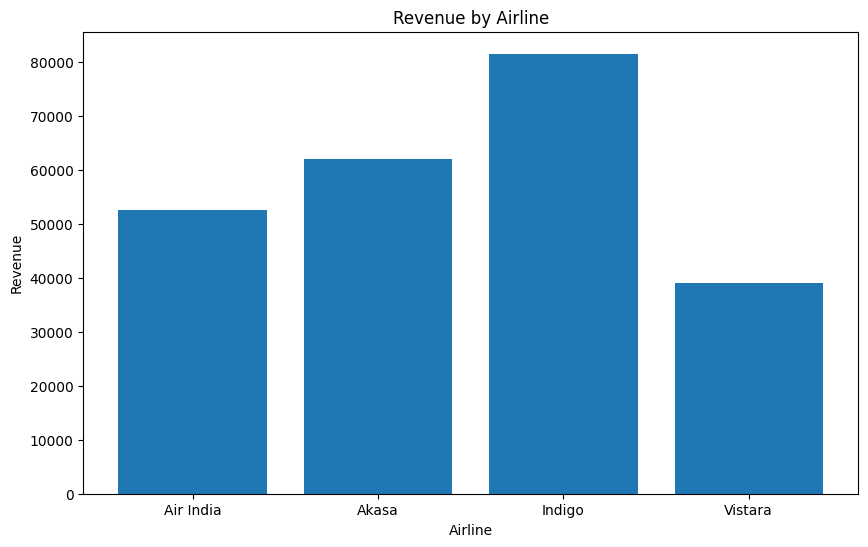

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

bookings_clean_df = bookings_df.withColumn("ticket_price", col("ticket_price").cast("int"))
flights_clean_df = flights_df.withColumn("duration", col("duration").cast("int"))

bookingflight_df = bookings_clean_df.join(flights_clean_df, "flight_id", "inner").join(preferences_df, "passenger_name", "inner")

#Revenue by Airline
rev_airline_df = bookingflight_df.groupBy("airline").agg(sum("ticket_price").alias("revenue")).toPandas()
plt.figure(figsize=(10, 6))
plt.bar(rev_airline_df["airline"], rev_airline_df["revenue"])
plt.xlabel("Airline")
plt.ylabel("Revenue")
plt.title("Revenue by Airline")
plt.show()

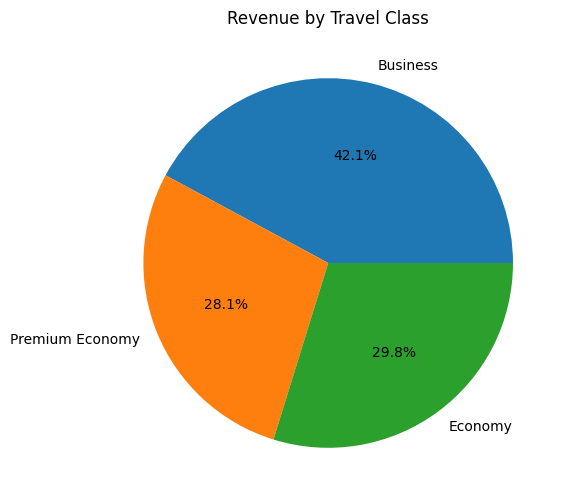

In [0]:
# Revenue by Travel Class
rev_travel_class_df = bookingflight_df.groupBy("travel_class").agg(sum("ticket_price").alias("revenue")).toPandas()
plt.figure(figsize=(6, 6))
plt.pie(rev_travel_class_df["revenue"], labels=rev_travel_class_df["travel_class"], autopct='%1.1f%%')
plt.title("Revenue by Travel Class")
plt.show()

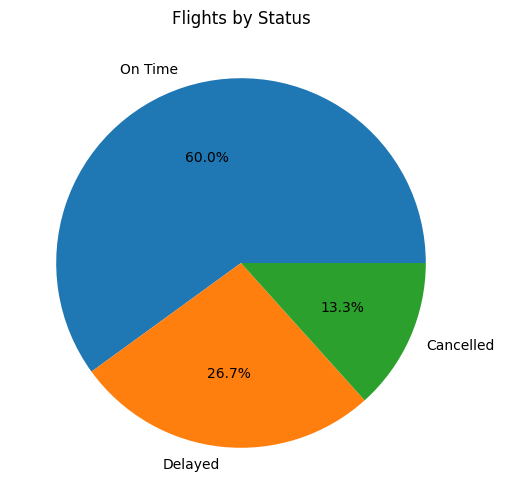

In [0]:
# Flights by Status
flights_status_df = flights_clean_df.groupBy("status").count().toPandas()
plt.figure(figsize=(6, 6))
plt.pie(flights_status_df["count"], labels=flights_status_df["status"], autopct='%1.1f%%')
plt.title("Flights by Status")
plt.show()

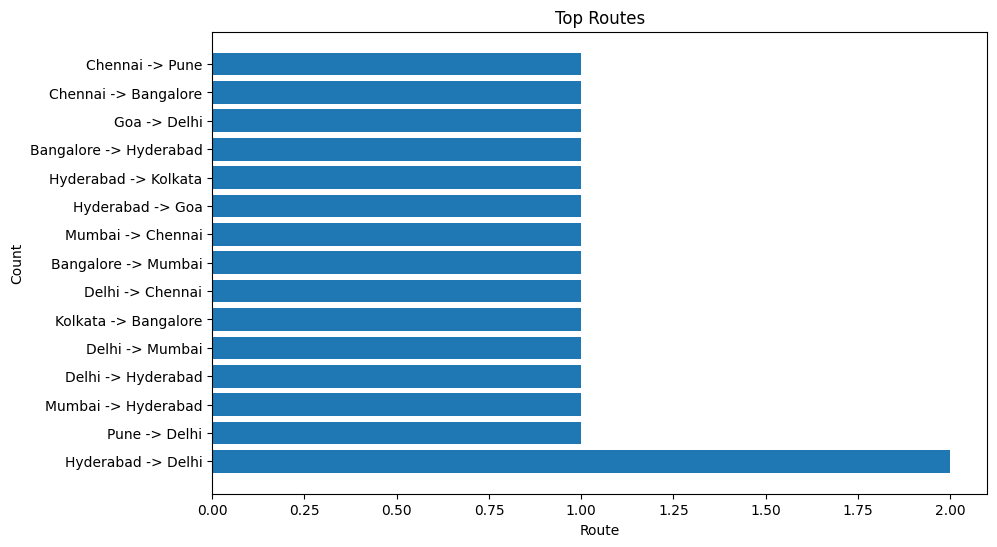

In [0]:
# Top Routes
top_routes_df = bookingflight_df.withColumn("route", concat_ws(" -> ", col("from_city"), col("to_city"))).groupBy("route").agg(count("*").alias("count")).orderBy(desc("count")).toPandas()
plt.figure(figsize=(10, 6))
plt.barh(top_routes_df["route"], top_routes_df["count"])
plt.xlabel("Route")
plt.ylabel("Count")
plt.title("Top Routes")
plt.show()

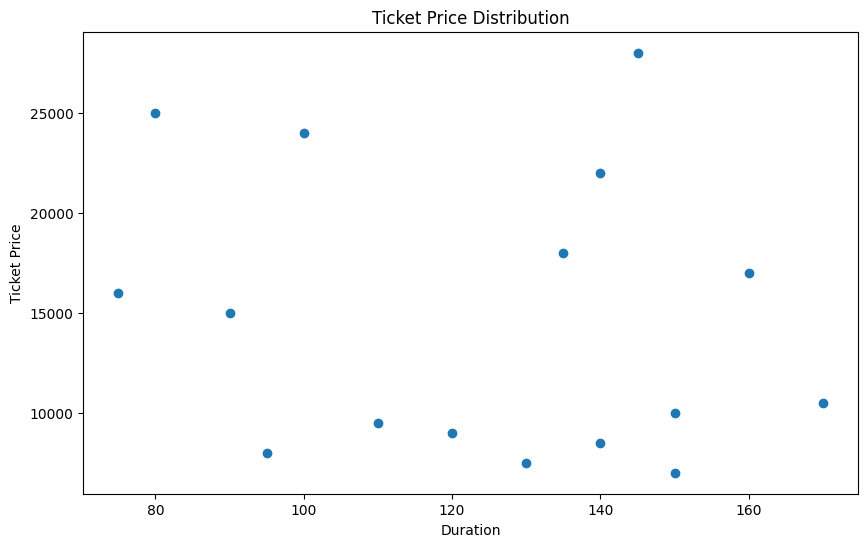

In [0]:
# Ticket Price Distribution
scatter_pt = bookingflight_df.select("duration", "ticket_price").toPandas()
plt.figure(figsize=(10, 6))
plt.scatter(scatter_pt["duration"], scatter_pt["ticket_price"])
plt.xlabel("Duration")
plt.ylabel("Ticket Price")
plt.title("Ticket Price Distribution")
plt.show()

### Part 3 : Transformations


In [0]:
trns_booking = bookings_clean_df.withColumn("revenue", col("ticket_price")).withColumn("price_band", when(col("ticket_price")>20000, "Premium").when(col("ticket_price")>10000, "Standard").otherwise("Budget"))
trns_booking.show()

+----------+---------+--------------+---------------+------------+------------+-------+----------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|revenue|price_band|
+----------+---------+--------------+---------------+------------+------------+-------+----------+
|     B1001|     F101|  Rahul Sharma|        Economy|        8500|  2026-06-01|   8500|    Budget|
|     B1002|     F101|   Priya Reddy|       Business|       22000|  2026-06-01|  22000|   Premium|
|     B1003|     F102|    Amit Kumar|        Economy|        9000|  2026-06-02|   9000|    Budget|
|     B1004|     F103|   Sneha Patel|Premium Economy|       15000|  2026-06-02|  15000|  Standard|
|     B1005|     F104|    Farhan Ali|        Economy|        7500|  2026-06-03|   7500|    Budget|
|     B1006|     F105|    Neha Singh|       Business|       25000|  2026-06-03|  25000|   Premium|
|     B1007|     F106|   Arjun Verma|        Economy|       10000|  2026-06-04|  10000|    Budget|
|     B100

In [0]:
delay_flg = flights_df.withColumn("delay_flag", when(col("status")=="Delayed", "Yes").otherwise("No"))
delay_flg.show()

+---------+---------+---------+---------+--------+---------+----------+
|flight_id|  airline|from_city|  to_city|duration|   status|delay_flag|
+---------+---------+---------+---------+--------+---------+----------+
|     F101|   Indigo|Hyderabad|    Delhi|     140|  On Time|        No|
|     F102|Air India|   Mumbai|  Chennai|     120|  Delayed|       Yes|
|     F103|  Vistara|Bangalore|Hyderabad|      90|  On Time|        No|
|     F104|   Indigo|    Delhi|   Mumbai|     130|Cancelled|        No|
|     F105|Air India|  Chennai|Bangalore|      80|  On Time|        No|
|     F106|    Akasa|     Pune|    Delhi|     150|  Delayed|       Yes|
|     F107|  Vistara|Hyderabad|  Kolkata|     160|  On Time|        No|
|     F108|   Indigo|   Mumbai|Hyderabad|     110|  On Time|        No|
|     F109|    Akasa|    Delhi|  Chennai|     145|  Delayed|       Yes|
|     F110|Air India|Bangalore|   Mumbai|      95|  On Time|        No|
|     F111|   Indigo|Hyderabad|      Goa|      75|  On Time|    

### Part 4 : Joins

In [0]:
print("Complete Passenger Journey Dataset Schema:")
bookingflight_df.printSchema()
print("Complete Passenger Journey Dataset:")
display(bookingflight_df)

Complete Passenger Journey Dataset Schema:
root
 |-- passenger_name: string (nullable = true)
 |-- flight_id: string (nullable = true)
 |-- booking_id: string (nullable = true)
 |-- travel_class: string (nullable = true)
 |-- ticket_price: integer (nullable = true)
 |-- booking_date: date (nullable = true)
 |-- airline: string (nullable = true)
 |-- from_city: string (nullable = true)
 |-- to_city: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- status: string (nullable = true)
 |-- extra_baggage: boolean (nullable = true)
 |-- meal: string (nullable = true)
 |-- seat: string (nullable = true)

Complete Passenger Journey Dataset:


passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,airline,from_city,to_city,duration,status,extra_baggage,meal,seat
Rahul Sharma,F101,B1001,Economy,8500,2026-06-01,Indigo,Hyderabad,Delhi,140,On Time,true,Veg,Window
Priya Reddy,F101,B1002,Business,22000,2026-06-01,Indigo,Hyderabad,Delhi,140,On Time,false,Non-Veg,Aisle
Amit Kumar,F102,B1003,Economy,9000,2026-06-02,Air India,Mumbai,Chennai,120,Delayed,false,Veg,Middle
Sneha Patel,F103,B1004,Premium Economy,15000,2026-06-02,Vistara,Bangalore,Hyderabad,90,On Time,true,Jain,Window
Farhan Ali,F104,B1005,Economy,7500,2026-06-03,Indigo,Delhi,Mumbai,130,Cancelled,false,Non-Veg,Aisle
Neha Singh,F105,B1006,Business,25000,2026-06-03,Air India,Chennai,Bangalore,80,On Time,true,Veg,Window
Arjun Verma,F106,B1007,Economy,10000,2026-06-04,Akasa,Pune,Delhi,150,Delayed,false,Veg,Middle
Meera Nair,F107,B1008,Premium Economy,17000,2026-06-04,Vistara,Hyderabad,Kolkata,160,On Time,true,Jain,Window
Kiran Rao,F108,B1009,Economy,9500,2026-06-05,Indigo,Mumbai,Hyderabad,110,On Time,false,Veg,Aisle
Nisha Reddy,F109,B1010,Business,28000,2026-06-05,Akasa,Delhi,Chennai,145,Delayed,true,Non-Veg,Window


### Part 5 : Spark SQL


In [0]:
bookingflight_df.createOrReplaceTempView("passenger_journey")

In [0]:
print("Revenue by Airline:")
rev_airline_df = spark.sql("SELECT airline, SUM(CAST(ticket_price AS INT)) AS revenue FROM passenger_journey GROUP BY airline ORDER BY revenue DESC")
display(rev_airline_df)

Revenue by Airline:


airline,revenue
Indigo,81500
Akasa,62000
Air India,52500
Vistara,39000


In [0]:
print("Revenue by Route:")
rev_route = spark.sql("SELECT from_city, to_city, CONCAT(from_city, '->', to_city) AS route, SUM(CAST(ticket_price AS INT)) AS revenue FROM passenger_journey GROUP BY from_city, to_city ORDER BY revenue DESC")
display(rev_route)

Revenue by Route:


from_city,to_city,route,revenue
Hyderabad,Delhi,Hyderabad->Delhi,30500
Delhi,Chennai,Delhi->Chennai,28000
Chennai,Bangalore,Chennai->Bangalore,25000
Chennai,Pune,Chennai->Pune,24000
Delhi,Hyderabad,Delhi->Hyderabad,18000
Hyderabad,Kolkata,Hyderabad->Kolkata,17000
Hyderabad,Goa,Hyderabad->Goa,16000
Bangalore,Hyderabad,Bangalore->Hyderabad,15000
Kolkata,Bangalore,Kolkata->Bangalore,10500
Pune,Delhi,Pune->Delhi,10000


In [0]:
print("Average ticket price:")
display(spark.sql("SELECT AVG(CAST(ticket_price AS INT)) AS average_ticket_price FROM passenger_journey"))

print("Most popular destination:")
display(spark.sql("SELECT to_city AS destination, COUNT(*) AS total_bookings FROM passenger_journey GROUP BY to_city ORDER BY total_bookings DESC LIMIT 1"))

Average ticket price:


average_ticket_price
14687.5


Most popular destination:


destination,total_bookings
Delhi,4


### Part 6 : Window Functions


In [0]:
from pyspark.sql.window import Window
flight_rev = bookingflight_df.groupBy("flight_id", "airline").agg(sum("ticket_price").alias("revenue"))
rev_w = Window.orderBy(desc("revenue"))
print("Top 3 Revenue Flights")
top_3_flights = flight_rev.withColumn("rank", rank().over(rev_w)).filter(col("rank") <= 3)
display(top_3_flights)

Top 3 Revenue Flights


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


flight_id,airline,revenue,rank
F101,Indigo,30500,1
F109,Akasa,28000,2
F105,Air India,25000,3


In [0]:
route_rev = bookingflight_df.withColumn("route", concat_ws("->", col("from_city"), col("to_city"))).groupBy("airline","route").agg(sum("ticket_price").alias("revenue"))
airline_w = Window.partitionBy("airline").orderBy(desc("revenue"))
print("Top routes by Airlines")
top_routes = route_rev.withColumn("rank", rank().over(airline_w))
display(top_routes.filter(col("rank") <= 5))

Top routes by Airlines


airline,route,revenue,rank
Air India,Chennai->Bangalore,25000,1
Air India,Kolkata->Bangalore,10500,2
Air India,Mumbai->Chennai,9000,3
Air India,Bangalore->Mumbai,8000,4
Akasa,Delhi->Chennai,28000,1
Akasa,Chennai->Pune,24000,2
Akasa,Pune->Delhi,10000,3
Indigo,Hyderabad->Delhi,30500,1
Indigo,Delhi->Hyderabad,18000,2
Indigo,Hyderabad->Goa,16000,3


In [0]:
running_w = Window.orderBy("booking_date").rowsBetween(Window.unboundedPreceding, Window.currentRow)
print("Running total of revenue:")
running_rev = bookingflight_df.withColumn("running_revenue",sum("ticket_price").over(running_w))
running_rev = running_rev.select("booking_date", "passenger_name", "ticket_price", "running_revenue")

display(running_rev)

Running total of revenue:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


booking_date,passenger_name,ticket_price,running_revenue
2026-06-01,Rahul Sharma,8500,8500
2026-06-01,Priya Reddy,22000,30500
2026-06-02,Amit Kumar,9000,39500
2026-06-02,Sneha Patel,15000,54500
2026-06-03,Farhan Ali,7500,62000
2026-06-03,Neha Singh,25000,87000
2026-06-04,Arjun Verma,10000,97000
2026-06-04,Meera Nair,17000,114000
2026-06-05,Kiran Rao,9500,123500
2026-06-05,Nisha Reddy,28000,151500


In [0]:
rank_airline = Window.partitionBy("airline").orderBy(desc("revenue"))
airline_rev = flight_rev.withColumn("rank", rank().over(rank_airline))
display(airline_rev)

flight_id,airline,revenue,rank
F105,Air India,25000,1
F114,Air India,10500,2
F102,Air India,9000,3
F110,Air India,8000,4
F109,Akasa,28000,1
F113,Akasa,24000,2
F106,Akasa,10000,3
F101,Indigo,30500,1
F115,Indigo,18000,2
F111,Indigo,16000,3


In [0]:
dest = bookingflight_df.groupBy("to_city").agg(count("*").alias("total"))
d_w = Window.orderBy(desc("total"))
print("Dense Rank destinations:")
dense_dest = dest.withColumn("rank", dense_rank().over(d_w))
display(dense_dest)

Dense Rank destinations:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


to_city,total,rank
Delhi,4,1
Hyderabad,3,2
Chennai,2,3
Bangalore,2,3
Mumbai,2,3
Kolkata,1,4
Pune,1,4
Goa,1,4


### Part 7 : Delta Lake

In [0]:
path = "/dbfs/mnt/delta/passenger_journey"
# Method 1 save
bookingflight_df.write.format("delta").mode("overwrite").save(path)
print("Delta table successfully")

Delta table successfully


In [0]:
# Method 2 saveAsTable
bookingflight_df.write.format("delta").mode("overwrite").saveAsTable("passenger_journey")
print("Delta table successfully")

Delta table successfully


In [0]:
# Method 3 using DELTA
bookingflight_df.createOrReplaceTempView("tmp_table")
spark.sql("CREATE TABLE IF NOT EXISTS passenger_journey USING DELTA AS SELECT * FROM tmp_table")
print("Delta table successfully")

Delta table successfully


###Part 8 : Incremental Load
 

In [0]:
from delta.tables import DeltaTable
from io import StringIO
import csv

day2_incremental_csv = """booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,9200,2026-06-01
B1003,F102,Amit Kumar,Economy,9800,2026-06-02
B1007,F106,Arjun Verma,Economy,11000,2026-06-04
B1011,F110,David Thomas,Economy,8700,2026-06-06
B1015,F114,Sanjay Gupta,Economy,12000,2026-06-08
B1021,F101,Karan Johar,Economy,8500,2026-06-11
B1022,F102,Rohan Das,Business,21000,2026-06-11
B1023,F104,Simran Kaur,Economy,7500,2026-06-12
B1024,F105,Aditya Roy,Business,26000,2026-06-12
B1025,F108,Zoya Akhtar,Economy,9000,2026-06-13
B1026,F111,Kabir Khan,Premium Economy,16500,2026-06-13
B1027,F113,Preity Zinta,Business,24500,2026-06-14
B1028,F115,Ravi Shastri,Premium Economy,18500,2026-06-14
B1029,F103,Gaurav Kapoor,Business,22500,2026-06-15
B1030,F107,Alia Bhatt,Economy,9300,2026-06-15
"""
f = StringIO(day2_incremental_csv.strip())
reader = csv.reader(f)
headers = next(reader)
data = [tuple(row) for row in reader]

day2_updates_df = spark.createDataFrame(data, schema=headers)
day2_updates_df = day2_updates_df.withColumn("ticket_price", col("ticket_price").cast("int"))
target_delta_table = DeltaTable.forPath(spark, path)
target_delta_table.alias("target").merge(
        source=day2_updates_df.alias("source"),
        condition="target.booking_id = source.booking_id"
    ).whenMatchedUpdate(set={
        "ticket_price": "source.ticket_price",
        "booking_date": "source.booking_date",
        "travel_class": "source.travel_class"
    }).whenNotMatchedInsert(values={
        "booking_id": "source.booking_id",
        "flight_id": "source.flight_id",
        "passenger_name": "source.passenger_name",
        "travel_class": "source.travel_class",
        "ticket_price": "source.ticket_price",
        "booking_date": "source.booking_date"
    }).execute()

print("Incremental Load Operation Concluded Successfully.")

Incremental Load Operation Concluded Successfully.


### Part 9 : Time Travel


In [0]:
print("Version 0:")
df_version_0 = spark.read.format("delta").option("versionAsOf", 0).load(path)
display(df_version_0)
print("Version 1:")
df_version_1 = spark.read.format("delta").option("versionAsOf", 1).load(path)
display(df_version_1)

print("Latest Version:")
df_latest = spark.read.format("delta").load(path)
display(df_latest)
print("Before and after Merge:")
display(df_version_0.subtract(df_version_1))

Version 0:


passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,airline,from_city,to_city,duration,status,extra_baggage,meal,seat
Rahul Sharma,F101,B1001,Economy,8500,2026-06-01,Indigo,Hyderabad,Delhi,140,On Time,true,Veg,Window
Priya Reddy,F101,B1002,Business,22000,2026-06-01,Indigo,Hyderabad,Delhi,140,On Time,false,Non-Veg,Aisle
Amit Kumar,F102,B1003,Economy,9000,2026-06-02,Air India,Mumbai,Chennai,120,Delayed,false,Veg,Middle
Sneha Patel,F103,B1004,Premium Economy,15000,2026-06-02,Vistara,Bangalore,Hyderabad,90,On Time,true,Jain,Window
Farhan Ali,F104,B1005,Economy,7500,2026-06-03,Indigo,Delhi,Mumbai,130,Cancelled,false,Non-Veg,Aisle
Neha Singh,F105,B1006,Business,25000,2026-06-03,Air India,Chennai,Bangalore,80,On Time,true,Veg,Window
Arjun Verma,F106,B1007,Economy,10000,2026-06-04,Akasa,Pune,Delhi,150,Delayed,false,Veg,Middle
Meera Nair,F107,B1008,Premium Economy,17000,2026-06-04,Vistara,Hyderabad,Kolkata,160,On Time,true,Jain,Window
Kiran Rao,F108,B1009,Economy,9500,2026-06-05,Indigo,Mumbai,Hyderabad,110,On Time,false,Veg,Aisle
Nisha Reddy,F109,B1010,Business,28000,2026-06-05,Akasa,Delhi,Chennai,145,Delayed,true,Non-Veg,Window


Version 1:


passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,airline,from_city,to_city,duration,status,extra_baggage,meal,seat
Priya Reddy,F101,B1002,Business,22000,2026-06-01,Indigo,Hyderabad,Delhi,140,On Time,false,Non-Veg,Aisle
Sneha Patel,F103,B1004,Premium Economy,15000,2026-06-02,Vistara,Bangalore,Hyderabad,90,On Time,true,Jain,Window
Farhan Ali,F104,B1005,Economy,7500,2026-06-03,Indigo,Delhi,Mumbai,130,Cancelled,false,Non-Veg,Aisle
Neha Singh,F105,B1006,Business,25000,2026-06-03,Air India,Chennai,Bangalore,80,On Time,true,Veg,Window
Meera Nair,F107,B1008,Premium Economy,17000,2026-06-04,Vistara,Hyderabad,Kolkata,160,On Time,true,Jain,Window
Kiran Rao,F108,B1009,Economy,9500,2026-06-05,Indigo,Mumbai,Hyderabad,110,On Time,false,Veg,Aisle
Nisha Reddy,F109,B1010,Business,28000,2026-06-05,Akasa,Delhi,Chennai,145,Delayed,true,Non-Veg,Window
Ayesha Khan,F111,B1012,Premium Economy,16000,2026-06-06,Indigo,Hyderabad,Goa,75,On Time,true,Jain,Window
Rohit Sharma,F112,B1013,Economy,7000,2026-06-07,Vistara,Goa,Delhi,150,Cancelled,false,Veg,Aisle
Pooja Mehta,F113,B1014,Business,24000,2026-06-07,Akasa,Chennai,Pune,100,On Time,true,Non-Veg,Window


Latest Version:


passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,airline,from_city,to_city,duration,status,extra_baggage,meal,seat
Priya Reddy,F101,B1002,Business,22000,2026-06-01,Indigo,Hyderabad,Delhi,140,On Time,false,Non-Veg,Aisle
Sneha Patel,F103,B1004,Premium Economy,15000,2026-06-02,Vistara,Bangalore,Hyderabad,90,On Time,true,Jain,Window
Farhan Ali,F104,B1005,Economy,7500,2026-06-03,Indigo,Delhi,Mumbai,130,Cancelled,false,Non-Veg,Aisle
Neha Singh,F105,B1006,Business,25000,2026-06-03,Air India,Chennai,Bangalore,80,On Time,true,Veg,Window
Meera Nair,F107,B1008,Premium Economy,17000,2026-06-04,Vistara,Hyderabad,Kolkata,160,On Time,true,Jain,Window
Kiran Rao,F108,B1009,Economy,9500,2026-06-05,Indigo,Mumbai,Hyderabad,110,On Time,false,Veg,Aisle
Nisha Reddy,F109,B1010,Business,28000,2026-06-05,Akasa,Delhi,Chennai,145,Delayed,true,Non-Veg,Window
Ayesha Khan,F111,B1012,Premium Economy,16000,2026-06-06,Indigo,Hyderabad,Goa,75,On Time,true,Jain,Window
Rohit Sharma,F112,B1013,Economy,7000,2026-06-07,Vistara,Goa,Delhi,150,Cancelled,false,Veg,Aisle
Pooja Mehta,F113,B1014,Business,24000,2026-06-07,Akasa,Chennai,Pune,100,On Time,true,Non-Veg,Window


Before and after Merge:


passenger_name,flight_id,booking_id,travel_class,ticket_price,booking_date,airline,from_city,to_city,duration,status,extra_baggage,meal,seat
Arjun Verma,F106,B1007,Economy,10000,2026-06-04,Akasa,Pune,Delhi,150,Delayed,false,Veg,Middle
Sanjay Gupta,F114,B1015,Economy,10500,2026-06-08,Air India,Kolkata,Bangalore,170,Delayed,false,Veg,Middle
Rahul Sharma,F101,B1001,Economy,8500,2026-06-01,Indigo,Hyderabad,Delhi,140,On Time,true,Veg,Window
David Thomas,F110,B1011,Economy,8000,2026-06-06,Air India,Bangalore,Mumbai,95,On Time,false,Veg,Middle
Amit Kumar,F102,B1003,Economy,9000,2026-06-02,Air India,Mumbai,Chennai,120,Delayed,false,Veg,Middle


### Part 10 : Optimize Delta


In [0]:
spark.sql("DROP TABLE IF EXISTS j_o_b.default.passenger_journey")
bookingflight_df.write \
    .format("delta") \
    .mode("overwrite") \
    .option("mergeSchema", "true") \
    .saveAsTable("j_o_b.default.passenger_journey")

In [0]:
print("OPTIMIZE")
spark.sql("OPTIMIZE passenger_journey")

OPTIMIZE


DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,numOutputZCubes:bigint>,numBins:bigint,numBatches:bigint,totalConsideredFiles:bigint,totalFilesSkipped:bigint,preserveInsertionOrder:boolean,numFilesSkippedToReduceWriteAmplification:bigint,numBytesSkippedToReduceWriteAmplification:bigint,startTimeMs:bigint,endTimeMs:bigint,

In [0]:
print("ZORDER")
spark.sql("OPTIMIZE passenger_journey ZORDER BY (flight_id)")

ZORDER


DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,numOutputZCubes:bigint>,numBins:bigint,numBatches:bigint,totalConsideredFiles:bigint,totalFilesSkipped:bigint,preserveInsertionOrder:boolean,numFilesSkippedToReduceWriteAmplification:bigint,numBytesSkippedToReduceWriteAmplification:bigint,startTimeMs:bigint,endTimeMs:bigint,

In [0]:
print("VACUUM")
spark.sql("VACUUM passenger_journey")

VACUUM


DataFrame[path: string]

In [0]:
print("DESCRIBE HISTORY")
display(spark.sql("DESCRIBE HISTORY passenger_journey"))

DESCRIBE HISTORY


version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
2,2026-06-19T12:13:53.000Z,144530056129212,azuser7221_mml.local@karthikirisoutlook.onmicrosoft.com,VACUUM END,Map(status -> COMPLETED),null,List(4439325625830880),f2ef5397-12e4-42ce-a861-4ca599c4384c,0619-095529-npgm5iki-v2n,1,SnapshotIsolation,true,"Map(numDeletedFiles -> 0, numVacuumedDirectories -> 1)",null,Databricks-Runtime/18.2.x-photon-scala2.13
1,2026-06-19T12:13:52.000Z,144530056129212,azuser7221_mml.local@karthikirisoutlook.onmicrosoft.com,VACUUM START,"Map(retentionCheckEnabled -> true, defaultRetentionMillis -> 604800000)",null,List(4439325625830880),f2ef5397-12e4-42ce-a861-4ca599c4384c,0619-095529-npgm5iki-v2n,0,SnapshotIsolation,true,"Map(numFilesToDelete -> 0, sizeOfDataToDelete -> 0)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-19T12:10:53.000Z,144530056129212,azuser7221_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true, canMergeSchema -> true)",null,List(4439325625830880),4a020a31-715b-425e-baf4-a95aa8a87864,0619-095529-npgm5iki-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 16, numOutputBytes -> 4626)",null,Databricks-Runtime/18.2.x-photon-scala2.13


### Part 11 : Tables and Views


In [0]:
print("Managed Table")
bookingflight_df.write.format("delta").mode("overwrite").saveAsTable("passenger_journey_managed")
print("Table created")

Managed Table
Table created


In [0]:
print("External Table")
bookingflight_df.write.format("delta").mode("overwrite").saveAsTable("passenger_journey_external")
print("Table created")

External Table
Table created


In [0]:
# Temporary View
bookingflight_df.createOrReplaceTempView("tv_passenger_journey")

In [0]:
# Global Temporary View
bookingflight_df.createOrReplaceGlobalTempView("global_vw_passenger_journey")

Reports

In [0]:
print("=== FINAL REPORT: Airline Revenue Report ===")
airline_revenue_report = spark.sql("""
    SELECT 
        airline AS `Airline`,
        FORMAT_NUMBER(SUM(ticket_price), 0) AS `Revenue (INR)`
    FROM passenger_journey_external
    GROUP BY airline
    ORDER BY SUM(ticket_price) DESC
""")
display(airline_revenue_report)

=== FINAL REPORT: Airline Revenue Report ===


Airline,Revenue (INR)
Indigo,"81,500"
Akasa,"62,000"
Air India,"52,500"
Vistara,"39,000"


In [0]:
print("=== FINAL REPORT: Route Performance Report ===")
route_performance_report = spark.sql("""
    SELECT 
        CONCAT(from_city, ' -> ', to_city) AS `Route`,
        FORMAT_NUMBER(SUM(ticket_price), 0) AS `Revenue (INR)`
    FROM passenger_journey_external
    GROUP BY from_city, to_city
    ORDER BY SUM(ticket_price) DESC
""")

display(route_performance_report)

=== FINAL REPORT: Route Performance Report ===


Route,Revenue (INR)
Hyderabad -> Delhi,"30,500"
Delhi -> Chennai,"28,000"
Chennai -> Bangalore,"25,000"
Chennai -> Pune,"24,000"
Delhi -> Hyderabad,"18,000"
Hyderabad -> Kolkata,"17,000"
Hyderabad -> Goa,"16,000"
Bangalore -> Hyderabad,"15,000"
Kolkata -> Bangalore,"10,500"
Pune -> Delhi,"10,000"


In [0]:
print("=== FINAL REPORT: Passenger Preference Report ===")
passenger_preference_report = spark.sql("""
    SELECT 
        passenger_name AS `Passenger`,
        meal AS `Meal`,
        seat AS `Seat`
    FROM passenger_journey_external
    ORDER BY passenger_name ASC
""")

display(passenger_preference_report)

=== FINAL REPORT: Passenger Preference Report ===


Passenger,Meal,Seat
Amit Kumar,Veg,Middle
Arjun Verma,Veg,Middle
Ayesha Khan,Jain,Window
David Thomas,Veg,Middle
Divya Iyer,Jain,Window
Farhan Ali,Non-Veg,Aisle
Kiran Rao,Veg,Aisle
Meera Nair,Jain,Window
Neha Singh,Veg,Window
Nisha Reddy,Non-Veg,Window


In [0]:
print("=== FINAL REPORT: Flight Delay & Status Report ===")
flight_delay_report = spark.sql("""
    SELECT 
        flight_id AS `Flight`,
        status AS `Status`
    FROM passenger_journey_external
    GROUP BY flight_id, status
    ORDER BY status DESC, flight_id ASC
""")

display(flight_delay_report)

=== FINAL REPORT: Flight Delay & Status Report ===


Flight,Status
F101,On Time
F103,On Time
F105,On Time
F107,On Time
F108,On Time
F110,On Time
F111,On Time
F113,On Time
F115,On Time
F102,Delayed


In [0]:
print("=== FINAL REPORT: Top Revenue Flights ===")
top_revenue_flights_report = spark.sql("""
    WITH FlightRevenue AS (
        SELECT 
            flight_id AS `Flight`,
            SUM(ticket_price) as raw_revenue
        FROM passenger_journey_external
        GROUP BY flight_id
    )
    SELECT 
        `Flight`,
        RANK() OVER (ORDER BY raw_revenue DESC) AS `Rank`,
        FORMAT_NUMBER(raw_revenue, 0) AS `Revenue (INR)`
    FROM FlightRevenue
""")

display(top_revenue_flights_report)

=== FINAL REPORT: Top Revenue Flights ===


Flight,Rank,Revenue (INR)
F101,1,"30,500"
F109,2,"28,000"
F105,3,"25,000"
F113,4,"24,000"
F115,5,"18,000"
F107,6,"17,000"
F111,7,"16,000"
F103,8,"15,000"
F114,9,"10,500"
F106,10,"10,000"
